# EDA: Participant Match Rates

Exploratory analysis of mutual matches in the Columbia speed dating dataset.

**Research questions:**

1. On average, how many matches does a participant make?
2. What is the distribution of match counts across participants — left-skewed or right-skewed?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("..") / "data" / "Speed Dating Data.csv"
USECOLS = ["iid", "pid", "match"]

print(f"Data path: {DATA_PATH.resolve()}")

Data path: C:\SMU_MITB\RecSys\project_2\data\Speed Dating Data.csv


## Load data

Each row is one speed date: participant `iid` met partner `pid`. Column `match = 1` when both parties decided yes (mutual match).

In [2]:
def load_speed_dating(path: Path) -> pd.DataFrame:
    """Load CSV with encoding fallback and basic row-count validation."""
    for encoding in ("utf-8", "latin-1", "cp1252"):
        try:
            df = pd.read_csv(path, usecols=USECOLS, encoding=encoding, low_memory=False)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise UnicodeDecodeError("Could not decode CSV with utf-8, latin-1, or cp1252")

    if len(df) < 1000:
        raise ValueError(f"Expected ~8,000+ rows, got {len(df):,}. Check CSV line endings.")

    df = df.dropna(subset=["pid"]).copy()
    df["pid"] = df["pid"].astype(int)
    df["match"] = df["match"].fillna(0).astype(int)
    return df


df = load_speed_dating(DATA_PATH)
print(f"Loaded {len(df):,} interaction rows")
print(f"Unique participants (iid): {df['iid'].nunique():,}")
df.head()

Loaded 8,368 interaction rows
Unique participants (iid): 551


,iid,pid,match
0,1,11,0
1,1,12,0
2,1,13,1
3,1,14,1
4,1,15,1


## Matches per participant

Sum mutual `match` flags over all dates for each `iid`.

In [3]:
matches_per_iid = df.groupby("iid")["match"].sum()
matches_per_iid.name = "num_matches"
matches_per_iid.head(10)

iid
1     4
2     2
3     0
4     2
5     2
6     2
7     2
8     8
9     7
10    2
Name: num_matches, dtype: int64

## Q1: Average number of matches per participant

In [4]:
avg_matches = matches_per_iid.mean()
median_matches = matches_per_iid.median()
zero_match_share = (matches_per_iid == 0).mean()

print(f"Mean mutual matches per participant: {avg_matches:.2f}")
print(f"Median mutual matches per participant: {median_matches:.0f}")
print(f"Share of participants with zero matches: {zero_match_share:.1%}")
print()
matches_per_iid.describe()

Mean mutual matches per participant: 2.50
Median mutual matches per participant: 2
Share of participants with zero matches: 18.0%



count    551.000000
mean       2.504537
std        2.287412
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       14.000000
Name: num_matches, dtype: float64

## Q2: Distribution of match counts and skewness

| Signal | Right-skewed | Left-skewed |
|--------|--------------|-------------|
| Mean vs median | Mean > median | Mean < median |
| Skewness | Positive (> 0) | Negative (< 0) |
| Histogram tail | Long tail toward high counts | Long tail toward low counts |

In [5]:
skewness = matches_per_iid.skew()
print(f"Skewness (Fisher-Pearson): {skewness:.3f}")
print(f"Mean: {matches_per_iid.mean():.2f}  |  Median: {matches_per_iid.median():.0f}")

if skewness > 0 and matches_per_iid.mean() > matches_per_iid.median():
    skew_label = "right-skewed"
elif skewness < 0 and matches_per_iid.mean() < matches_per_iid.median():
    skew_label = "left-skewed"
else:
    skew_label = "approximately symmetric or mixed signals"
print(f"Conclusion: the distribution of match counts is {skew_label}.")

Skewness (Fisher-Pearson): 1.251
Mean: 2.50  |  Median: 2
Conclusion: the distribution of match counts is right-skewed.


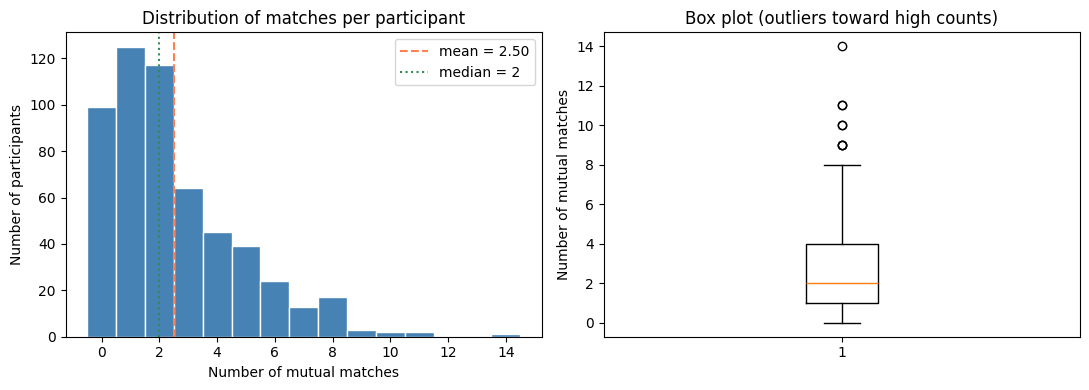

Value counts (matches -> participants):
num_matches
0      99
1     125
2     117
3      64
4      45
5      39
6      24
7      13
8      17
9       3
10      2
11      2
14      1


In [6]:
counts = matches_per_iid.value_counts().sort_index()
max_matches = int(matches_per_iid.max())
bins = np.arange(-0.5, max_matches + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(matches_per_iid, bins=bins, edgecolor="white", color="steelblue")
axes[0].axvline(avg_matches, color="coral", linestyle="--", label=f"mean = {avg_matches:.2f}")
axes[0].axvline(median_matches, color="seagreen", linestyle=":", label=f"median = {median_matches:.0f}")
axes[0].set_xlabel("Number of mutual matches")
axes[0].set_ylabel("Number of participants")
axes[0].set_title("Distribution of matches per participant")
axes[0].legend()

axes[1].boxplot(matches_per_iid, vert=True)
axes[1].set_ylabel("Number of mutual matches")
axes[1].set_title("Box plot (outliers toward high counts)")

plt.tight_layout()
plt.show()

print("Value counts (matches -> participants):")
print(counts.to_string())

# Pre-survey feature screening for content-based filtering

Candidate features come from the pre-event survey (one row per participant after deduplicating on `iid`). Survey fields repeat on every interaction row, so we profile at the **participant level**.

**Screening criteria:**

| Flag | Rule of thumb |
|------|----------------|
| **Drop** | Missing ≥ 30%, or free-text with a coded alternative, or redundant duplicate block |
| **Review** | Missing 10–30%, or very high cardinality text |
| **Keep** | Missing < 10%, reasonable variance, clear role in content-based matching |

**Feature roles in content-based filtering:**

- **Preference weights** (`attr1_1` …) — what a user wants in a partner
- **Self-profile** (`attr3_1` …) — how a user describes themselves (matched against others' preferences)
- **Interests / demographics** — additional similarity signals between users

In [17]:
# --- candidate pre-survey columns (grouped) ---
DEMO_COLS = [
    "age", "field", "field_cd", "undergra", "mn_sat", "tuition", "race",
    "imprace", "imprelig", "from", "zipcode", "income", "goal", "date",
    "go_out", "career", "career_c",
]
INTEREST_COLS = [
    "sports", "tvsports", "exercise", "dining", "museums", "art", "hiking",
    "gaming", "clubbing", "reading", "tv", "theater", "movies", "concerts",
    "music", "shopping", "yoga",
]
EXPECT_COLS = ["exphappy", "expnum"]
PREF_COLS = [
    "attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1",
    "attr4_1", "sinc4_1", "intel4_1", "fun4_1", "amb4_1", "shar4_1",
    "attr2_1", "sinc2_1", "intel2_1", "fun2_1", "amb2_1", "shar2_1",
]
SELF_COLS = [
    "attr3_1", "sinc3_1", "fun3_1", "intel3_1", "amb3_1",
    "attr5_1", "sinc5_1", "intel5_1", "fun5_1", "amb5_1",
]
FEATURE_COLS = DEMO_COLS + INTEREST_COLS + EXPECT_COLS + PREF_COLS + SELF_COLS
FEATURE_GROUPS = {
    "demographics": DEMO_COLS,
    "interests": INTEREST_COLS,
    "expectations": EXPECT_COLS,
    "preferences": PREF_COLS,
    "self_ratings": SELF_COLS,
}

MISS_DROP = 0.30
MISS_REVIEW = 0.10
TEXT_COLS = {"field", "undergra", "from", "career", "zipcode"}
CODED_ALTERNATIVES = {"field": "field_cd", "career": "career_c"}

print(f"Candidate features: {len(FEATURE_COLS)} columns across {len(FEATURE_GROUPS)} groups")

Candidate features: 64 columns across 5 groups


In [18]:
def load_survey_profiles(path: Path, cols: list[str]) -> pd.DataFrame:
    """Load pre-survey columns and return one profile row per participant."""
    usecols = ["iid"] + cols
    for encoding in ("utf-8", "latin-1", "cp1252"):
        try:
            raw = pd.read_csv(path, usecols=usecols, encoding=encoding, low_memory=False)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise UnicodeDecodeError("Could not decode CSV with utf-8, latin-1, or cp1252")

    profiles = raw.drop_duplicates("iid").set_index("iid").sort_index()
    return profiles


# gender is required for model feature selection and gender-stratified imputation
PROFILE_COLS = FEATURE_COLS + ["gender"]

profiles = load_survey_profiles(DATA_PATH, PROFILE_COLS)
print(f"Participant profiles: {len(profiles):,}")
profiles.head(3)

Participant profiles: 551


,gender,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,...,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1
iid,,,,,,,,,,,,,,,,,,,,,
1,0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,...,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN
2,0,24.0,law,1.0,NaN,NaN,NaN,2.0,2.0,5.0,...,7.0,5.0,10.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN
3,0,25.0,Economics,2.0,NaN,NaN,NaN,2.0,8.0,4.0,...,8.0,9.0,8.0,9.0,8.0,NaN,NaN,NaN,NaN,NaN


## Missing values

High missingness is the primary reason to drop a column. Columns with ≥ 30% missing are flagged **drop**; 10–30% are **review**.

Columns with any missing values:


,group,column,dtype,missing_pct,missing_flag
35,expectations,expnum,float64,0.771325,drop
4,demographics,mn_sat,str,0.633394,drop
5,demographics,tuition,str,0.575318,drop
11,demographics,income,str,0.490018,drop
59,self_ratings,attr5_1,float64,0.430127,drop
...,...,...,...,...,...
33,interests,yoga,float64,0.012704,keep
50,preferences,intel2_1,float64,0.012704,keep
51,preferences,fun2_1,float64,0.012704,keep
6,demographics,race,float64,0.010889,keep



Drop (missing ≥ 30%): ['expnum', 'mn_sat', 'tuition', 'income', 'attr5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'sinc5_1', 'undergra']
Review (missing 10%–30%): ['shar4_1', 'amb4_1', 'intel4_1', 'sinc4_1', 'fun4_1', 'attr4_1', 'zipcode']


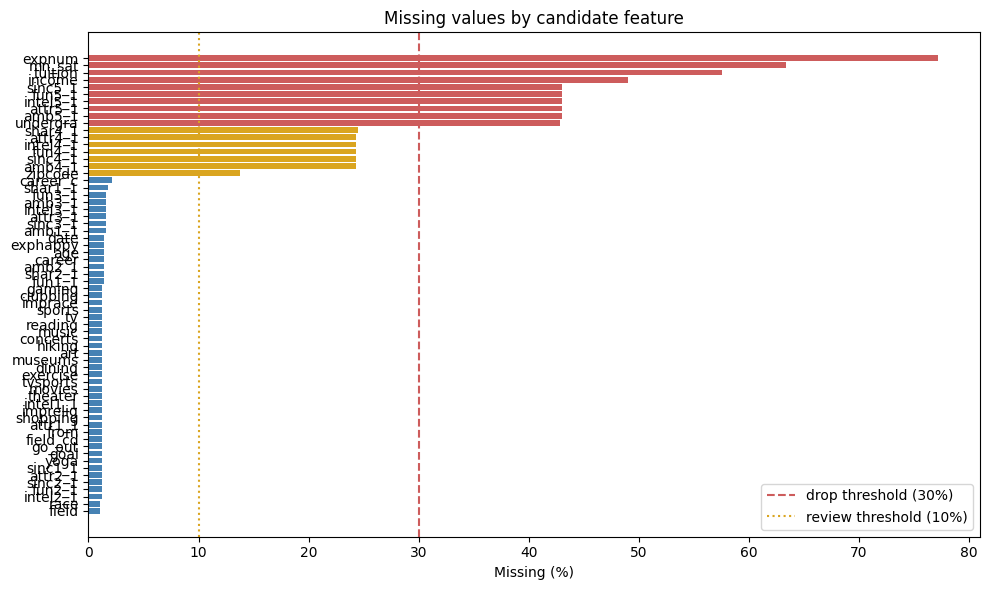

In [9]:
def missing_flag(pct: float) -> str:
    if pct >= MISS_DROP:
        return "drop"
    if pct >= MISS_REVIEW:
        return "review"
    return "keep"


missing_report = pd.DataFrame({
    "group": [g for g, cols in FEATURE_GROUPS.items() for _ in cols],
    "column": FEATURE_COLS,
    "dtype": profiles[FEATURE_COLS].dtypes.astype(str).values,
    "missing_pct": profiles[FEATURE_COLS].isna().mean().values,
})
missing_report["missing_flag"] = missing_report["missing_pct"].map(missing_flag)
missing_report = missing_report.sort_values("missing_pct", ascending=False)

print("Columns with any missing values:")
display(missing_report[missing_report["missing_pct"] > 0])

drop_missing = missing_report[missing_report["missing_flag"] == "drop"]["column"].tolist()
review_missing = missing_report[missing_report["missing_flag"] == "review"]["column"].tolist()
print(f"\nDrop (missing ≥ {MISS_DROP:.0%}): {drop_missing}")
print(f"Review (missing {MISS_REVIEW:.0%}–{MISS_DROP:.0%}): {review_missing}")

fig, ax = plt.subplots(figsize=(10, 6))
subset = missing_report[missing_report["missing_pct"] > 0].sort_values("missing_pct")
colors = subset["missing_flag"].map({"drop": "indianred", "review": "goldenrod", "keep": "steelblue"})
ax.barh(subset["column"], subset["missing_pct"] * 100, color=colors)
ax.axvline(MISS_DROP * 100, color="indianred", linestyle="--", label=f"drop threshold ({MISS_DROP:.0%})")
ax.axvline(MISS_REVIEW * 100, color="goldenrod", linestyle=":", label=f"review threshold ({MISS_REVIEW:.0%})")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing values by candidate feature")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Variance and discriminative power

For 1–10 rating scales, low standard deviation or a dominant modal value means the column adds little differentiation between users. Also flag columns where one value accounts for > 40% of responses.

In [10]:
SCALE_COLS = INTEREST_COLS + EXPECT_COLS + PREF_COLS + SELF_COLS + [
    "imprace", "imprelig", "goal", "date", "go_out", "age", "race",
]

variance_rows = []
for col in SCALE_COLS:
    s = profiles[col].dropna()
    if s.empty:
        continue
    top_pct = s.value_counts(normalize=True).iloc[0]
    variance_rows.append({
        "column": col,
        "group": next(g for g, cols in FEATURE_GROUPS.items() if col in cols),
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "nunique": s.nunique(),
        "top_value_pct": top_pct,
        "missing_pct": profiles[col].isna().mean(),
    })

variance_report = pd.DataFrame(variance_rows).sort_values("std")
variance_report["variance_flag"] = np.where(
    (variance_report["std"] < 1.0) | (variance_report["top_value_pct"] > 0.40),
    "review",
    "keep",
)

print("Lowest-variance numeric features:")
display(variance_report.head(15))

low_var = variance_report[variance_report["variance_flag"] == "review"]["column"].tolist()
print(f"Review for low variance / dominant mode: {low_var}")

Lowest-variance numeric features:


,column,group,n,mean,std,nunique,top_value_pct,missing_pct,variance_flag
40,intel3_1,self_ratings,542,8.385609,1.089700,8,0.354244,0.016334,keep
51,go_out,demographics,544,2.143382,1.104833,7,0.351103,0.012704,keep
53,race,demographics,545,2.800000,1.253818,5,0.557798,0.010889,review
44,intel5_1,self_ratings,314,8.257962,1.330528,8,0.312102,0.430127,keep
37,attr3_1,self_ratings,542,7.092251,1.390081,9,0.354244,0.016334,keep
38,sinc3_1,self_ratings,542,8.285978,1.412038,9,0.289668,0.016334,keep
49,goal,demographics,544,2.148897,1.448273,6,0.419118,0.012704,review
50,date,demographics,543,4.983425,1.468520,7,0.250460,0.014519,keep
42,attr5_1,self_ratings,314,6.929936,1.506597,9,0.353503,0.430127,keep
39,fun3_1,self_ratings,542,7.701107,1.547510,9,0.274908,0.016334,keep


Review for low variance / dominant mode: ['race', 'goal']


## Categorical and free-text cardinality

High-cardinality free-text fields are hard to use directly in content-based models (sparse, noisy). Prefer coded versions when available (`field_cd` over `field`, `career_c` over `career`).

In [11]:
CAT_COLS = ["field", "field_cd", "undergra", "from", "zipcode", "career", "career_c", "race"]

card_rows = []
for col in CAT_COLS:
    s = profiles[col]
    card_rows.append({
        "column": col,
        "missing_pct": s.isna().mean(),
        "nunique": s.nunique(),
        "top_value": s.value_counts(dropna=True).index[0] if s.notna().any() else None,
        "top_value_pct": s.value_counts(normalize=True, dropna=True).iloc[0] if s.notna().any() else np.nan,
        "coded_alternative": CODED_ALTERNATIVES.get(col, ""),
    })

card_report = pd.DataFrame(card_rows).sort_values("nunique", ascending=False)
card_report["cardinality_flag"] = np.select(
    [
        card_report["column"].isin(TEXT_COLS) & card_report["coded_alternative"].astype(bool),
        card_report["nunique"] > 50,
        card_report["missing_pct"] >= MISS_DROP,
    ],
    ["drop (use coded alt.)", "review (high cardinality)", "drop (missing)"],
    default="keep",
)
display(card_report)

drop_text = card_report[card_report["cardinality_flag"].str.startswith("drop")]["column"].tolist()
print(f"Drop or replace free-text: {drop_text}")

,column,missing_pct,nunique,top_value,top_value_pct,coded_alternative,cardinality_flag
4,zipcode,0.137931,409,0,0.048421,,review (high cardinality)
5,career,0.014519,367,Finance,0.023941,career_c,drop (use coded alt.)
3,from,0.012704,269,New York,0.066176,,review (high cardinality)
0,field,0.010889,259,Business,0.064220,field_cd,drop (use coded alt.)
2,undergra,0.428312,241,Columbia,0.019048,,review (high cardinality)
1,field_cd,0.012704,18,8.0,0.238971,,keep
6,career_c,0.021779,17,2.0,0.282004,,keep
7,race,0.010889,5,2.0,0.557798,,keep


Drop or replace free-text: ['career', 'field']


## Redundancy across attribute blocks

The survey asks similar preference questions in multiple blocks (`*_1_1`, `*_4_1`, `*_2_1`) and self-ratings in two blocks (`*_3_1`, `*_5_1`). Highly correlated duplicates add noise without new signal — keep one block per role.

Preference block correlations (moderate — some overlap but not identical):


,dimension,"r(pref1, pref4)","r(pref1, pref2)","r(pref4, pref2)",n_pairs
0,attr,0.488579,0.380338,0.484731,417
1,sinc,0.287703,0.227531,0.255836,417
2,intel,0.208907,0.175961,0.164015,417
3,fun,0.280165,0.290728,0.356411,417
4,amb,0.151843,0.101854,-0.064719,417
5,shar,0.198612,0.425798,0.274019,416



Self-rating block correlations (self3 vs self5):


,dimension,"r(self3, self5)",n_pairs,self5_missing_pct
0,attr,0.842762,314,0.430127
1,sinc,0.599595,314,0.430127
2,intel,0.716818,314,0.430127
3,fun,0.788791,314,0.430127
4,amb,0.618167,314,0.430127


→ self5 block is ~43% missing and highly correlated with self3; prefer self3 only.


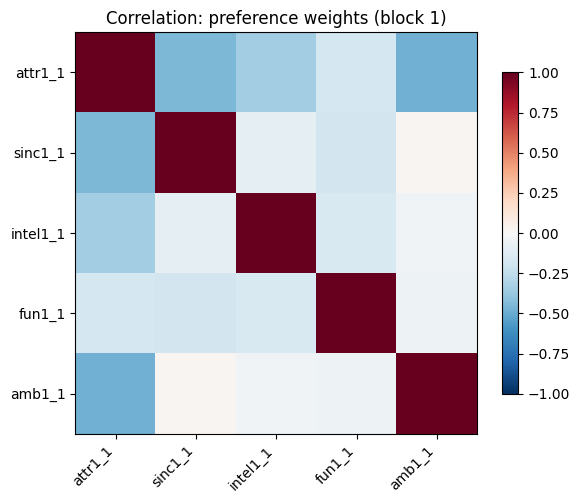

In [12]:
DIMS = ["attr", "sinc", "intel", "fun", "amb", "shar"]

# Preference blocks: corr(attr*_1, attr*_4, attr*_2)
pref_corr_rows = []
for dim in DIMS:
    cols = [f"{dim}1_1", f"{dim}4_1", f"{dim}2_1"]
    sub = profiles[cols].dropna()
    if len(sub) < 10:
        continue
    c = sub.corr()
    pref_corr_rows.append({
        "dimension": dim,
        "r(pref1, pref4)": c.iloc[0, 1],
        "r(pref1, pref2)": c.iloc[0, 2],
        "r(pref4, pref2)": c.iloc[1, 2],
        "n_pairs": len(sub),
    })
pref_corr = pd.DataFrame(pref_corr_rows)
print("Preference block correlations (moderate — some overlap but not identical):")
display(pref_corr)

# Self-rating blocks: *_3_1 vs *_5_1 (shar not in self5)
self_corr_rows = []
for dim in ["attr", "sinc", "intel", "fun", "amb"]:
    a, b = f"{dim}3_1", f"{dim}5_1"
    sub = profiles[[a, b]].dropna()
    if len(sub) < 10:
        continue
    self_corr_rows.append({
        "dimension": dim,
        "r(self3, self5)": sub[a].corr(sub[b]),
        "n_pairs": len(sub),
        "self5_missing_pct": profiles[b].isna().mean(),
    })
self_corr = pd.DataFrame(self_corr_rows)
print("\nSelf-rating block correlations (self3 vs self5):")
display(self_corr)
print("→ self5 block is ~43% missing and highly correlated with self3; prefer self3 only.")

# Heatmap: preference block 1 (already used in prototype)
pref1_cols = [f"{d}1_1" for d in ["attr", "sinc", "intel", "fun", "amb"]]
corr_pref1 = profiles[pref1_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_pref1, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(pref1_cols)), pref1_cols, rotation=45, ha="right")
ax.set_yticks(range(len(pref1_cols)), pref1_cols)
ax.set_title("Correlation: preference weights (block 1)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Recommended candidate pool

Consolidated flags from missingness, cardinality, variance, and redundancy checks.

In [13]:
DROP_EXPLICIT = {
    # Heavy missing
    "undergra", "mn_sat", "tuition", "income", "expnum",
    # Redundant self-rating block (prefer *_3_1; 43% missing, r>0.6 with self3)
    "attr5_1", "sinc5_1", "intel5_1", "fun5_1", "amb5_1",
    # Free-text replaced by coded columns
    "field", "career",
    # High-cardinality location text (weak signal for content-based similarity)
    "from", "zipcode",
}

REVIEW_EXPLICIT = {
    # ~24% missing; overlaps with pref block 1
    "attr4_1", "sinc4_1", "intel4_1", "fun4_1", "amb4_1", "shar4_1",
}

KEEP_CORE = {
    # Prototype content-based columns
    "attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1",
    "attr3_1", "sinc3_1", "intel3_1", "fun3_1", "amb3_1",
}

KEEP_ADDITIONAL = {
    # Demographics / coded categoricals — low missing, usable directly
    "age", "race", "field_cd", "career_c", "goal", "date", "go_out",
    "imprace", "imprelig", "exphappy",
    # Interest vector — low missing, good spread (std ≈ 1.7–2.8)
    *INTEREST_COLS,
    # Optional second preference block (lower missing than pref4)
    "attr2_1", "sinc2_1", "intel2_1", "fun2_1", "amb2_1", "shar2_1",
    "shar1_1",
}


def final_recommendation(col: str) -> str:
    if col in DROP_EXPLICIT:
        return "drop"
    if col in REVIEW_EXPLICIT:
        return "review"
    if col in KEEP_CORE or col in KEEP_ADDITIONAL:
        return "keep"
    return "review"


def column_group(col: str) -> str:
    for group, cols in FEATURE_GROUPS.items():
        if col in cols:
            return group
    return ""


summary = pd.DataFrame({
    "column": FEATURE_COLS,
    "group": [column_group(c) for c in FEATURE_COLS],
    "missing_pct": profiles[FEATURE_COLS].isna().mean().values,
})
summary["recommendation"] = summary["column"].map(final_recommendation)
summary["rationale"] = summary["column"].map({
    "undergra": "43% missing + high-cardinality text",
    "mn_sat": "63% missing",
    "tuition": "58% missing",
    "income": "49% missing",
    "expnum": "77% missing",
    "field": "use field_cd instead (18 levels vs 259 text values)",
    "career": "use career_c instead (17 levels vs 367 text values)",
    "from": "269 unique free-text locations",
    "zipcode": "14% missing, 409 unique values",
    "attr5_1": "43% missing; r≈0.84 with attr3_1",
    "attr4_1": "24% missing; moderate overlap with block 1",
    "attr1_1": "prototype preference weight",
    "attr3_1": "prototype self-profile",
    "sports": "interest scale; std≈2.3, <2% missing",
}).fillna("")

for label in ["keep", "review", "drop"]:
    cols = summary.loc[summary["recommendation"] == label, "column"].tolist()
    print(f"\n{label.upper()} ({len(cols)}):")
    print(", ".join(cols))

display(summary.sort_values(["recommendation", "missing_pct"], ascending=[True, False]))


KEEP (44):
age, field_cd, race, imprace, imprelig, goal, date, go_out, career_c, sports, tvsports, exercise, dining, museums, art, hiking, gaming, clubbing, reading, tv, theater, movies, concerts, music, shopping, yoga, exphappy, attr1_1, sinc1_1, intel1_1, fun1_1, amb1_1, shar1_1, attr2_1, sinc2_1, intel2_1, fun2_1, amb2_1, shar2_1, attr3_1, sinc3_1, fun3_1, intel3_1, amb3_1

REVIEW (6):
attr4_1, sinc4_1, intel4_1, fun4_1, amb4_1, shar4_1

DROP (14):
field, undergra, mn_sat, tuition, from, zipcode, income, career, expnum, attr5_1, sinc5_1, intel5_1, fun5_1, amb5_1


,column,group,missing_pct,recommendation,rationale
35,expnum,expectations,0.771325,drop,77% missing
4,mn_sat,demographics,0.633394,drop,63% missing
5,tuition,demographics,0.575318,drop,58% missing
11,income,demographics,0.490018,drop,49% missing
59,attr5_1,self_ratings,0.430127,drop,43% missing; r≈0.84 with attr3_1
...,...,...,...,...,...
42,attr4_1,preferences,0.243194,review,24% missing; moderate overlap with block 1
43,sinc4_1,preferences,0.243194,review,
44,intel4_1,preferences,0.243194,review,
45,fun4_1,preferences,0.243194,review,


# Imputation strategy for model features

**Selected columns:** all **KEEP** features from the screening above, plus `gender`.

**Missingness profile (551 participants):**

- `gender` has **0%** missing — no imputation needed.
- Only **19 participants** (~3.4%) have any missing KEEP values.
- **7 participants** are missing **41–44 of 45** features (incomplete surveys).
- **12 participants** have **light** missingness (1–5 features).

**Recommended two-step strategy:**

| Step | Rule | Rationale |
|------|------|-----------|
| 1. Exclude | Drop participants with **>30%** missing KEEP features | Imputing 40+ values would fabricate entire profiles with no real signal |
| 2. Impute remainder | **Gender-stratified median** for numeric/ordinal scales; **gender-stratified mode** for coded categoricals | Preferences differ by gender (e.g. `attr1_1` median 15 vs 23); matches are evaluated within opposite-gender pools |

Fallback to the **global** median/mode when a gender group has no observed values for that column.

In [19]:
MODEL_COLS = sorted(KEEP_CORE | KEEP_ADDITIONAL | {"gender"})
NUMERIC_COLS = [
    c for c in MODEL_COLS
    if c not in {"gender", "race", "field_cd", "career_c"}
]
CATEGORICAL_COLS = ["race", "field_cd", "career_c"]
EXCLUDE_MISSING_THRESHOLD = 0.30  # drop participants above this share of missing KEEP cols

model_profiles = profiles[MODEL_COLS].copy()
missing_per_participant = model_profiles.isna().mean(axis=1)
exclude_mask = missing_per_participant > EXCLUDE_MISSING_THRESHOLD

print(f"Model features: {len(MODEL_COLS)} columns")
print(f"Participants with any missing: {model_profiles.isna().any(axis=1).sum()}")
print(f"Exclude (> {EXCLUDE_MISSING_THRESHOLD:.0%} missing): {exclude_mask.sum()} → iids {exclude_mask[exclude_mask].index.tolist()}")
print(f"Light missing (impute): {(missing_per_participant > 0).sum() - exclude_mask.sum()}")

light_missing = model_profiles.loc[missing_per_participant > 0].copy()
light_missing["missing_count"] = light_missing.isna().sum(axis=1)
display(light_missing[light_missing["missing_count"] > 0].assign(exclude=exclude_mask))

Model features: 45 columns
Participants with any missing: 19
Exclude (> 30% missing): 7 → iids [28, 58, 59, 136, 339, 340, 346]
Light missing (impute): 12


,age,amb1_1,amb2_1,amb3_1,art,attr1_1,attr2_1,attr3_1,career_c,clubbing,...,sinc1_1,sinc2_1,sinc3_1,sports,theater,tv,tvsports,yoga,missing_count,exclude
iid,,,,,,,,,,,,,,,,,,,,,
1,21.0,15.0,5.0,7.0,1.0,15.0,35.0,6.0,NaN,5.0,...,20.0,20.0,8.0,9.0,1.0,9.0,2.0,1.0,1,False
2,24.0,0.0,0.0,3.0,6.0,45.0,65.0,7.0,NaN,8.0,...,5.0,0.0,5.0,3.0,9.0,1.0,2.0,1.0,1,False
3,25.0,10.0,0.0,8.0,5.0,35.0,50.0,8.0,NaN,5.0,...,10.0,0.0,9.0,3.0,7.0,8.0,8.0,7.0,1,False
28,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,True
40,25.0,10.0,10.0,5.0,8.0,25.0,40.0,3.0,NaN,9.0,...,20.0,0.0,10.0,4.0,5.0,5.0,9.0,2.0,2,False
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44,True
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44,True
114,20.0,10.0,10.0,7.0,3.0,20.0,30.0,7.0,NaN,6.0,...,20.0,10.0,9.0,6.0,6.0,7.0,8.0,2.0,1,False
129,NaN,NaN,10.0,8.0,5.0,40.0,40.0,8.0,7.0,6.0,...,20.0,21.0,8.0,7.0,4.0,4.0,4.0,6.0,3,False


In [20]:
def _first_mode(series: pd.Series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if not modes.empty else np.nan


def impute_model_profiles(
    df: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    exclude_threshold: float = 0.30,
) -> tuple[pd.DataFrame, pd.Series]:
    """Return imputed profiles and a boolean mask of excluded participants."""
    out = df.copy()
    missing_share = out.isna().mean(axis=1)
    exclude_mask = missing_share > exclude_threshold

    impute_base = out.loc[~exclude_mask]
    global_num = impute_base[numeric_cols].median()
    global_cat = impute_base[categorical_cols].agg(_first_mode)

    for col in numeric_cols:
        fill = impute_base.groupby("gender")[col].transform("median")
        fill = fill.fillna(global_num[col])
        out.loc[~exclude_mask, col] = out.loc[~exclude_mask, col].fillna(fill)

    for col in categorical_cols:
        gender_mode = impute_base.groupby("gender")[col].agg(_first_mode)
        for gender, value in gender_mode.items():
            mask = (~exclude_mask) & (out["gender"] == gender) & out[col].isna()
            out.loc[mask, col] = value
        out.loc[~exclude_mask, col] = out.loc[~exclude_mask, col].fillna(global_cat[col])

    return out, exclude_mask


profiles_imputed, excluded = impute_model_profiles(
    model_profiles,
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    exclude_threshold=EXCLUDE_MISSING_THRESHOLD,
)

usable = profiles_imputed.loc[~excluded]
remaining_missing = usable[MODEL_COLS].isna().sum().sum()
print(f"Excluded participants: {excluded.sum()}")
print(f"Usable participants after exclusion + imputation: {len(usable)}")
print(f"Remaining missing values in usable profiles: {remaining_missing}")
assert remaining_missing == 0, "Imputation incomplete — check fallback logic"
usable.head(3)

Excluded participants: 7
Usable participants after exclusion + imputation: 544
Remaining missing values in usable profiles: 0


,age,amb1_1,amb2_1,amb3_1,art,attr1_1,attr2_1,attr3_1,career_c,clubbing,...,shar2_1,shopping,sinc1_1,sinc2_1,sinc3_1,sports,theater,tv,tvsports,yoga
iid,,,,,,,,,,,,,,,,,,,,,
1,21.0,15.0,5.0,7.0,1.0,15.0,35.0,6.0,2.0,5.0,...,5.0,8.0,20.0,20.0,8.0,9.0,1.0,9.0,2.0,1.0
2,24.0,0.0,0.0,3.0,6.0,45.0,65.0,7.0,2.0,8.0,...,0.0,3.0,5.0,0.0,5.0,3.0,9.0,1.0,2.0,1.0
3,25.0,10.0,0.0,8.0,5.0,35.0,50.0,8.0,2.0,5.0,...,0.0,8.0,10.0,0.0,9.0,3.0,7.0,8.0,8.0,7.0


## Imputation validation

Compare distributions before (complete cases only) vs after imputation for columns that were actually filled.

Columns with at least one imputed value: ['age', 'amb1_1', 'amb2_1', 'amb3_1', 'attr3_1', 'career_c', 'date', 'exphappy', 'field_cd', 'fun1_1', 'fun3_1', 'intel3_1', 'shar1_1', 'shar2_1', 'sinc3_1']


,column,n_imputed,median_before,median_after,mean_before,mean_after
5,career_c,5,6.0,6.000,5.250464,5.229779
12,shar1_1,3,11.0,10.935,11.832126,11.827923
1,amb1_1,2,10.0,10.000,10.806476,10.803511
4,attr3_1,2,7.0,7.000,7.092251,7.091912
3,amb3_1,2,8.0,8.000,7.577491,7.579044
10,fun3_1,2,8.0,8.000,7.701107,7.702206
0,age,2,26.0,26.000,26.359779,26.360294
11,intel3_1,2,8.0,8.000,8.385609,8.386029
14,sinc3_1,2,8.0,8.000,8.285978,8.286765
6,date,1,5.0,5.000,4.983425,4.983456


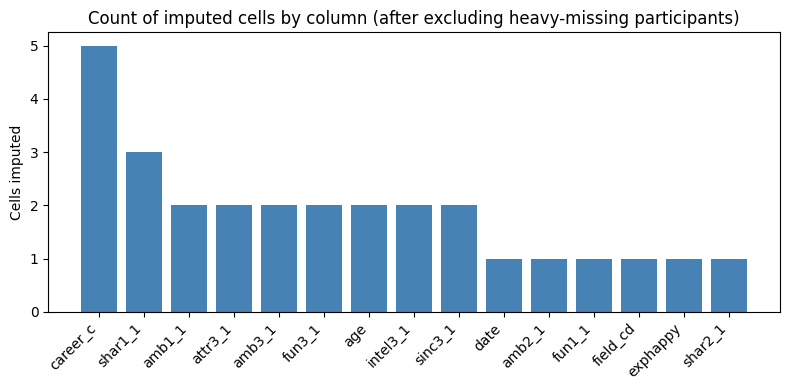

In [21]:
imputed_cells = model_profiles.loc[~excluded].isna() & usable.notna()
cols_imputed = imputed_cells.any(axis=0)
cols_imputed = cols_imputed[cols_imputed].index.tolist()

print(f"Columns with at least one imputed value: {cols_imputed}")

compare_rows = []
for col in cols_imputed:
    before = model_profiles.loc[~excluded, col].dropna()
    after = usable[col]
    compare_rows.append({
        "column": col,
        "n_imputed": int(imputed_cells[col].sum()),
        "median_before": before.median(),
        "median_after": after.median(),
        "mean_before": before.mean(),
        "mean_after": after.mean(),
    })

compare_report = pd.DataFrame(compare_rows).sort_values("n_imputed", ascending=False)
display(compare_report)

# Imputed values are small in number; medians should stay stable
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(compare_report["column"], compare_report["n_imputed"], color="steelblue")
ax.set_ylabel("Cells imputed")
ax.set_title("Count of imputed cells by column (after excluding heavy-missing participants)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Summary — use in your content-based model

```python
# profiles_imputed: one row per iid, KEEP + gender, imputed
# excluded: boolean mask — True for 7 participants with near-empty surveys
usable_profiles = profiles_imputed.loc[~excluded]
```

| Column type | Imputation | Examples |
|-------------|------------|----------|
| `gender` | None (0% missing) | `gender` |
| Numeric / ordinal (1–10 scales, age) | Gender-stratified **median** → global median fallback | `attr1_1`, `sports`, `age`, `goal` |
| Coded categoricals | Gender-stratified **mode** → global mode fallback | `race`, `field_cd`, `career_c` |
| Near-empty profiles | **Exclude** (>30% KEEP features missing) | 7 participants removed |

This keeps **544 of 551** participants with complete, model-ready profiles and only **~30 cell-level imputations** across the remaining 12 lightly incomplete surveys.